In [1]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, LearningCurveDisplay
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')

In [2]:
result = pyreadr.read_r("listings.RData")
data = result['listings']
data.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [3]:
data['price'] = data['price'].astype(str)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = data['price'].str.replace(',', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])

data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata', 'media', 'cara'])

print("Distribución de categorías:")
print(data['price_cat'].value_counts().sort_index())
print(f"\nRangos de precio:")
print(pd.qcut(data['price'], 3).value_counts().sort_index())

Distribución de categorías:
price_cat
barata    25689
media     25153
cara      25404
Name: count, dtype: int64

Rangos de precio:
price
(7.999, 143.0]      25689
(143.0, 268.0]      25153
(268.0, 50123.0]    25404
Name: count, dtype: int64


In [4]:
data['es_cara']   = (data['price_cat'] == 'cara').astype(int)
data['es_media']  = (data['price_cat'] == 'media').astype(int)
data['es_barata'] = (data['price_cat'] == 'barata').astype(int)

print(data[['price', 'price_cat', 'es_cara', 'es_media', 'es_barata']].head(10))

   price price_cat  es_cara  es_media  es_barata
0   97.0    barata        0         0          1
1  160.0     media        0         1          0
2   38.0    barata        0         0          1
3  145.0     media        0         1          0
4   58.0    barata        0         0          1
5   49.0    barata        0         0          1
6  300.0      cara        1         0          0
7  150.0     media        0         1          0
8  165.0     media        0         1          0
9  117.0    barata        0         0          1


In [5]:
X = data[['accommodates', 'bathrooms', 'bedrooms', 'beds',
          'minimum_nights', 'number_of_reviews', 'review_scores_rating']]

X = X.dropna()
y = data['es_cara'][X.index]

print(f"Tamaño de X: {X.shape}")
print(f"Distribución de y (es_cara):")
print(y.value_counts())

Tamaño de X: (62722, 7)
Distribución de y (es_cara):
es_cara
0    43784
1    18938
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts())

Entrenamiento: 43905 filas
Prueba:        18817 filas

Distribución en entrenamiento:
es_cara
0    30732
1    13173
Name: count, dtype: int64


In [7]:
logReg = LogisticRegression(solver='liblinear', random_state=42)
logReg.fit(X_train, y_train)

cv_scores = cross_val_score(logReg, X_train, y_train, cv=5, scoring='accuracy')

print("=== REGRESIÓN LOGÍSTICA ===")
print(f"\nValidación cruzada (5 folds):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nPromedio CV : {cv_scores.mean():.4f}")
print(f"Desv. std   : {cv_scores.std():.4f}")

print(f"\nCoeficientes del modelo:")
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': logReg.coef_[0]
}).sort_values('Coeficiente', ascending=False)
print(coef_df)

=== REGRESIÓN LOGÍSTICA ===

Validación cruzada (5 folds):
  Fold 1: 0.7907
  Fold 2: 0.7907
  Fold 3: 0.7983
  Fold 4: 0.7892
  Fold 5: 0.7932

Promedio CV : 0.7924
Desv. std   : 0.0032

Coeficientes del modelo:
               Variable  Coeficiente
1             bathrooms     0.794939
6  review_scores_rating     0.514315
0          accommodates     0.174099
2              bedrooms     0.132596
3                  beds     0.087829
5     number_of_reviews    -0.004404
4        minimum_nights    -0.011112


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.astype(float)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===")
print(vif_data)
print("\nInterpretación:")
print("VIF < 5  → sin multicolinealidad")
print("VIF 5-10 → multicolinealidad moderada")
print("VIF > 10 → multicolinealidad alta (problema)")

=== ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===
               Variable        VIF
0          accommodates  17.804823
2              bedrooms  11.408927
3                  beds  11.063951
1             bathrooms   9.781066
6  review_scores_rating   5.954905
5     number_of_reviews   1.477000
4        minimum_nights   1.237445

Interpretación:
VIF < 5  → sin multicolinealidad
VIF 5-10 → multicolinealidad moderada
VIF > 10 → multicolinealidad alta (problema)


In [10]:
print(X.corr().round(2))

                      accommodates  bathrooms  bedrooms  beds  minimum_nights  \
accommodates                  1.00       0.70      0.82  0.85           -0.12   
bathrooms                     0.70       1.00      0.75  0.67           -0.04   
bedrooms                      0.82       0.75      1.00  0.79           -0.04   
beds                          0.85       0.67      0.79  1.00           -0.08   
minimum_nights               -0.12      -0.04     -0.04 -0.08            1.00   
number_of_reviews            -0.10      -0.14     -0.11 -0.08           -0.12   
review_scores_rating          0.06       0.05      0.08  0.06           -0.03   

                      number_of_reviews  review_scores_rating  
accommodates                      -0.10                  0.06  
bathrooms                         -0.14                  0.05  
bedrooms                          -0.11                  0.08  
beds                              -0.08                  0.06  
minimum_nights                 

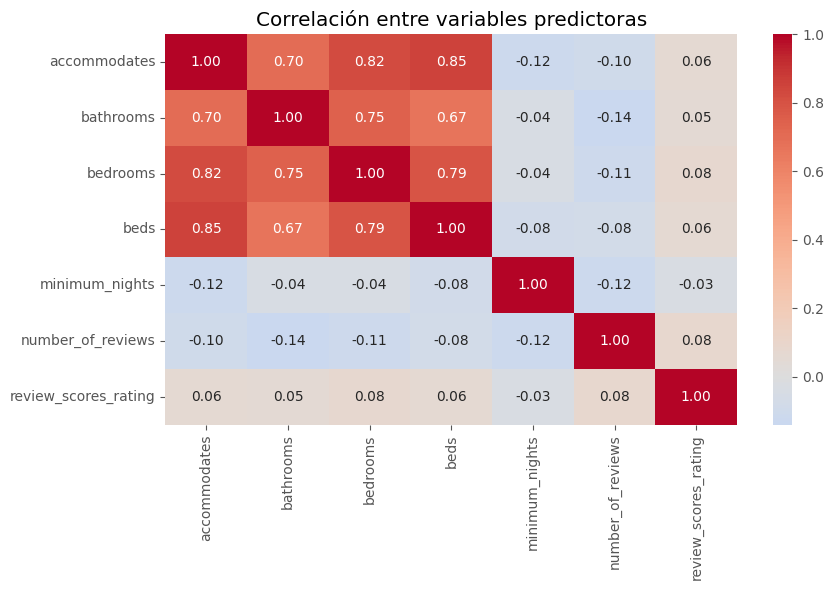

In [11]:
plt.figure(figsize=(9, 6))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre variables predictoras')
plt.tight_layout()
plt.show()

In [12]:
print("=== VARIABLES Y SU APORTE AL MODELO ===")
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': logReg.coef_[0]
}).sort_values('Coeficiente', ascending=False)

coef_df['Impacto'] = coef_df['Coeficiente'].apply(
    lambda x: 'Positivo (sube probabilidad de cara)' if x > 0 
    else 'Negativo (baja probabilidad de cara)'
)
print(coef_df.to_string(index=False))

=== VARIABLES Y SU APORTE AL MODELO ===
            Variable  Coeficiente                              Impacto
           bathrooms     0.794939 Positivo (sube probabilidad de cara)
review_scores_rating     0.514315 Positivo (sube probabilidad de cara)
        accommodates     0.174099 Positivo (sube probabilidad de cara)
            bedrooms     0.132596 Positivo (sube probabilidad de cara)
                beds     0.087829 Positivo (sube probabilidad de cara)
   number_of_reviews    -0.004404 Negativo (baja probabilidad de cara)
      minimum_nights    -0.011112 Negativo (baja probabilidad de cara)


In [13]:
y_pred = logReg.predict(X_test)

print("=== RESULTADOS EN CONJUNTO DE PRUEBA ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No cara', 'Cara']))

=== RESULTADOS EN CONJUNTO DE PRUEBA ===
Accuracy: 0.7908

              precision    recall  f1-score   support

     No cara       0.80      0.92      0.86     13052
        Cara       0.74      0.49      0.59      5765

    accuracy                           0.79     18817
   macro avg       0.77      0.71      0.72     18817
weighted avg       0.78      0.79      0.78     18817



In [14]:
y_pred_train = logReg.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred)

print("=== ANÁLISIS DE SOBREAJUSTE ===")
print(f"Accuracy Entrenamiento : {acc_train:.4f}")
print(f"Accuracy Prueba        : {acc_test:.4f}")
print(f"Diferencia             : {abs(acc_train - acc_test):.4f}")

if abs(acc_train - acc_test) > 0.05:
    print("Posible sobreajuste")
else:
    print("El modelo generaliza adecuadamente, sin sobreajuste")

=== ANÁLISIS DE SOBREAJUSTE ===
Accuracy Entrenamiento : 0.7926
Accuracy Prueba        : 0.7908
Diferencia             : 0.0019
El modelo generaliza adecuadamente, sin sobreajuste


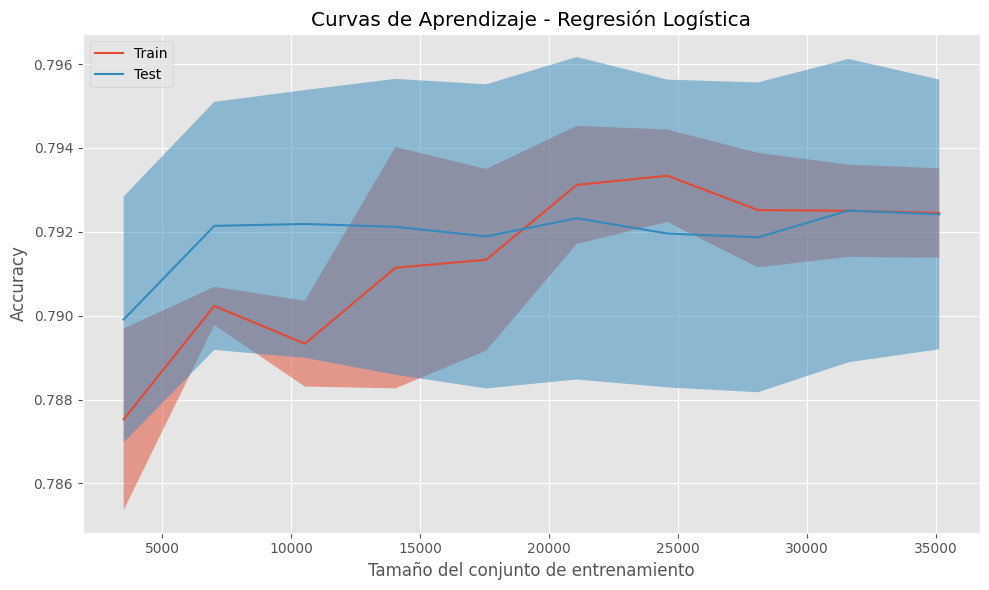

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

LearningCurveDisplay.from_estimator(
    logReg, X_train, y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    ax=ax
)

ax.set_title('Curvas de Aprendizaje - Regresión Logística')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.show()